# Penalized Cox-PH  

Goal of this notebook is to: 
- Ridge Regression Example 
- Cross-Validation Procedure  

## 0. Preliminaries  

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random 
import warnings

%matplotlib inline

from sklearn import set_config
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.exceptions import FitFailedWarning

from sksurv.datasets import load_breast_cancer
from sksurv.linear_model import CoxnetSurvivalAnalysis, CoxPHSurvivalAnalysis
from sksurv.preprocessing import OneHotEncoder
from sksurv.metrics import concordance_index_censored

set_config(display="text")  # displays text representation of estimators

In [2]:
X, y = load_breast_cancer()
Xt = OneHotEncoder().fit_transform(X)

## 1. Ridge Regression Example


In [3]:
alphas = 10.0 ** np.linspace(-4, 4, 50)
coefficients = {}

cph = CoxPHSurvivalAnalysis()
for alpha in alphas:
    cph.set_params(alpha=alpha)
    cph.fit(Xt, y)
    key = round(alpha, 5)
    coefficients[key] = cph.coef_

coefficients = pd.DataFrame.from_dict(coefficients).rename_axis(index="feature", columns="alpha").set_index(Xt.columns)

Now we can inspect how the coefficients change for varying $\alpha$  

In [4]:
def plot_coefficients(coefs, n_highlight):
    _, ax = plt.subplots(figsize=(9, 6))
    alphas = coefs.columns
    for row in coefs.itertuples():
        ax.semilogx(alphas, row[1:], ".-", label=row.Index)

    alpha_min = alphas.min()
    top_coefs = coefs.loc[:, alpha_min].map(abs).sort_values().tail(n_highlight)
    for name in top_coefs.index:
        coef = coefs.loc[name, alpha_min]
        plt.text(alpha_min, coef, name + "   ", horizontalalignment="right", verticalalignment="center")

    ax.yaxis.set_label_position("right")
    ax.yaxis.tick_right()
    ax.grid(True)
    ax.set_xlabel("alpha")
    ax.set_ylabel("coefficient")

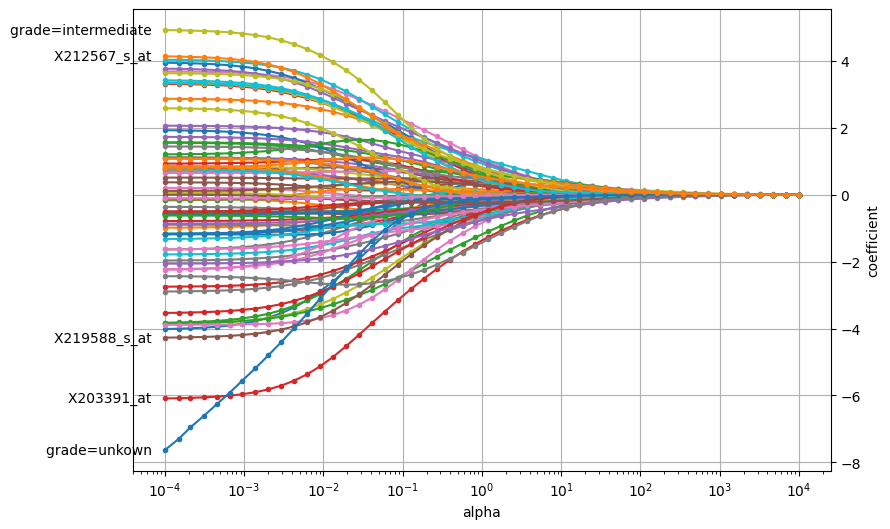

In [5]:
plot_coefficients(coefficients, n_highlight=5)

## 2. Cross-Validation Procedure 

For every run, we split into $k$ folds.  
- Each run "shuffles" the fold indices  

For every fold, we split *the data* into train, validation, and test. 
- We fit the model using the train data, and find the best parameters using the validation dataset  
- Once we have found the best set of parameters with the validation dataset, we use the best parameters and model and get the Test evaluation metrics  

In essence, 
- Train-Validation Phase is where the model "learns"  
- Test set checks how well model performs on data it hasn't seen before  

Here's a nice [article](https://www.solwey.com/posts/the-importance-of-cross-validation-in-machine-learning#:~:text=Cross%2Dvalidation%20gives%20a%20full,really%20understand%20how%20they%20learn.) that summarizes the importance of using Cross-Validation and the Types of Cross-Validation that exists.



In [ ]:
seed = 123
random.seed(seed)
np.random.seed(seed)

event_indicator = y["e.tdm"]
test_size = 0.10
n_splits = 5
n_runs = 5
l1_ratio = 1 # LASSO estimate, tune this between (0, 1] for elastic net, and close to 0 for ridge regression
fold_metrics = [] # Store fold estimates 

for run in range(n_runs): 
    print(f"\n=== Run {run + 1} ===") # recall that Python starts from 0 instead of 1 
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed+run) # Create the stratified folds 
    
    for fold, (trainval_index, test_index) in enumerate(kf.split(Xt, event_indicator)):
        print(f"\n--- Fold {fold + 1} ---")

        # Split into Train-Validation and Test Sets, DO NOT TOUCH TEST until evaluating your model
        X_trainval, X_test = Xt.iloc[trainval_index], Xt.iloc[test_index]
        y_trainval, y_test = y[trainval_index], y[test_index]

        # Now split Train and Validation 
        X_train, X_val, y_train, y_val = train_test_split(
            X_trainval, 
            y_trainval, 
            test_size=test_size, 
            random_state=seed + run + fold)
        
        best_val_cindex = -np.inf
        best_alpha = None

        # 1) fit once on TRAIN to get alpha path (find the candidate alphas)
        base_pipe = make_pipeline(
            StandardScaler(), 
            CoxnetSurvivalAnalysis(
                l1_ratio=l1_ratio,
                alpha_min_ratio=0.01,
                max_iter=100,
                fit_baseline_model=True,
            ),
        )
        warnings.simplefilter("ignore", UserWarning)
        warnings.simplefilter("ignore", FitFailedWarning)
        base_pipe.fit(X_train, y_train)

        scaler = base_pipe.named_steps["standardscaler"] # <- Standardizing Features is impt! 
        coxnet = base_pipe.named_steps["coxnetsurvivalanalysis"]
        alphas = coxnet.alphas_

        # 2) choose alpha on VAL (like you do with LR in MTL)
        X_val_scaled = scaler.transform(X_val) 
        best_alpha = None
        best_val_c = -np.inf

        for alpha in alphas: 
            print(f"Testing alpha: {alpha}")
            risk_val = coxnet.predict(X_val_scaled, alpha=float(alpha))
            cindex_val = concordance_index_censored(y_val["e.tdm"], y_val["t.tdm"], risk_val)[0]

            if cindex_val > best_val_cindex:
                best_val_cindex = cindex_val
                best_alpha = alpha
            print(f"Best alpha (by val C-index): {best_alpha} | val C-index={best_val_cindex:.3f}")

        # 3) evaluate that SAME trained path on TEST
        X_test_scaled = scaler.transform(X_test)
        risk_test = coxnet.predict(X_test_scaled, alpha=best_alpha)
        cindex_test = concordance_index_censored(
                    y_test["e.tdm"],
                    y_test["t.tdm"],
                    risk_test)[0]
        print(f"Test C-index: {cindex_test:.3f}")
        
        fold_metrics.append({
                    "run": run + 1,
                    "fold": fold + 1,
                    "val_cindex": best_val_cindex,
                    "test_cindex": cindex_test,
                    "alpha": best_alpha,
                })

fold_metrics_df = pd.DataFrame(fold_metrics) 


=== Run 1 ===

--- Fold 1 ---
Testing alpha: 0.13291066076344787
Best alpha (by val C-index): 0.13291066076344787 | val C-index=0.500
Testing alpha: 0.12686966610565376
Best alpha (by val C-index): 0.13291066076344787 | val C-index=0.500
Testing alpha: 0.121103243978354
Best alpha (by val C-index): 0.13291066076344787 | val C-index=0.500
Testing alpha: 0.11559891463627936
Best alpha (by val C-index): 0.11559891463627936 | val C-index=0.551
Testing alpha: 0.11034476555784356
Best alpha (by val C-index): 0.11034476555784356 | val C-index=0.592
Testing alpha: 0.10532942566395148
Best alpha (by val C-index): 0.11034476555784356 | val C-index=0.592
Testing alpha: 0.10054204070860226
Best alpha (by val C-index): 0.11034476555784356 | val C-index=0.592
Testing alpha: 0.09597224978802758
Best alpha (by val C-index): 0.11034476555784356 | val C-index=0.592
Testing alpha: 0.09161016291752576
Best alpha (by val C-index): 0.11034476555784356 | val C-index=0.592
Testing alpha: 0.0874463396274634
B

In [7]:
print(fold_metrics_df)

    run  fold  val_cindex  test_cindex     alpha
0     1     1    0.836735     0.773109  0.047766
1     1     2    0.827586     0.670886  0.006155
2     1     3    0.814815     0.811146  0.028920
3     1     4    0.714286     0.568389  0.014818
4     1     5    0.714286     0.741176  0.032953
5     2     1    0.826087     0.728916  0.046226
6     2     2    0.951220     0.757042  0.016809
7     2     3    0.666667     0.667674  0.002000
8     2     4    0.714286     0.622449  0.044462
9     2     5    0.567568     0.680124  0.042310
10    3     1    0.820225     0.709589  0.046929
11    3     2    0.609375     0.801262  0.006816
12    3     3    0.857143     0.746875  0.014869
13    3     4    0.806452     0.495385  0.127367
14    3     5    0.735849     0.501901  0.101941
15    4     1    0.600000     0.798762  0.033356
16    4     2    0.769231     0.506623  0.051225
17    4     3    0.877193     0.713433  0.038670
18    4     4    0.877551     0.647239  0.037375
19    4     5    0.8

From our metrics table, the most important metric we care about is `test_cindex`. So we want to visualize its distribution.

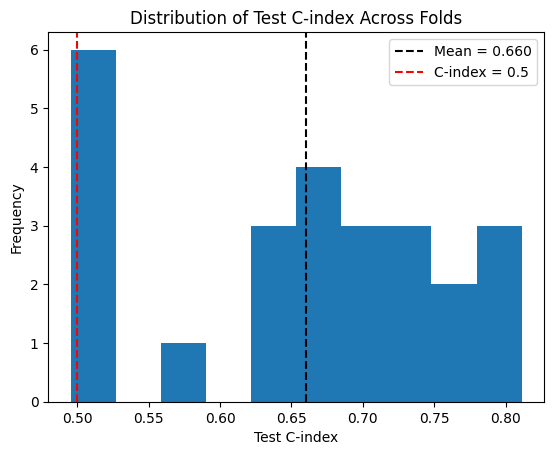

In [8]:
# Extract values
cindex_values = fold_metrics_df['test_cindex'].values

# Compute mean
mean_cindex = np.mean(cindex_values)

# Create histogram
plt.figure()
plt.hist(cindex_values, bins=10)

# Add vertical line at mean
plt.axvline(mean_cindex, linestyle='--', label=f'Mean = {mean_cindex:.3f}', color = 'black')

# Add vertical line at 0.5
plt.axvline(0.5, linestyle='--', label='C-index = 0.5', color = 'red')

# Labels and legend
plt.xlabel('Test C-index')
plt.ylabel('Frequency')
plt.title('Distribution of Test C-index Across Folds')
plt.legend()

plt.show()

We see that our C-index appears to be above random, but it isn't great. 

### Pseudo-Code for Cross-Validation

Step 0. SET YOUR SEEDS 
Step 1. `n_runs`, `n_splits`, `test_size`, and any fixed parameters outside of the loop  
Step 2. Define your loop 

    for run in range(n_runs): 
        kf = StratifiedKFold() <- Split into Folds 
        
        for fold, (trainval_index, test_index) in enumerate(kf.split(Xt, event_indicator)):<- this should give you the fold indices

            # Split 1: TrainVal + Test
            X_trainval, y_trainval = ... 
            X_test, y_test = ... 

            # Split 2: Train + Val
            X_train, X_val, y_train, y_val = train_test_split()

            # Any misc. data-processing (i.e., feature-scaling) 

            best_validation_metric = -np.inf (or something super low) 
            best_model = NULL <- defining the best model is important when you have to deal with weights (will come up in PyTorch)
            for param in parameters: <- loop through parameters 
                
                # Train Model 
                model = SomeModel(X_train, y_train, parameters = param) <- whatever you initialize it with

                # Validate the Model
                validation_metric = model.predict(X_val, y_val) 

                if validation_metric > best_validation_metric: 
                    # store best metrics & model 
                    best_validation_metric = validation_metric 
                    best_model = current_model
                    best_params = param 
            
    
            # Get metrics and store this output! 
            test_metric = model.predict(X_test, y_test, parameters = best_params) 